<a href="https://colab.research.google.com/github/sadikinisaac/AIML/blob/main/LandCover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
def is_prime(n):
  if n < 2 :
    return False
  for i in range (2,n):
    if n % i == 0 :
      return False
  return True


print(is_prime(2))
print(is_prime(4))
print(is_prime(6))
print(is_prime(13))

True
False
False
True


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00
All imports successful!
Boundary downloaded.
  ✓ Farmland: 50 features
  ✓ Forest: 1031 features
  ✓ Nature Reserve: 14 features
  ✓ Meadow / Grass: 2916 features
  ✓ Allotments: 106 features
  ✓ Cemetery: 34 features
  ✓ Military Base: 117 features
  ✓ Park: 2823 features
  ✓ Residential: 3808 features
  ✓ Commercial: 503 features
  ✓ Retail: 156 features
  ✓ Industrial: 630 features
  ✓ Lake / Reservoir: 1588 features
  – Vineyard: no features found

All land-cover layers downloaded!
  ✓ Motorway: 1353 segments
  ✓ Federal Highway: 439 segments
  ✓ Street: 585 segments
  ✓ Rivers/waterways: 1154 features

Roads and waterways downloaded!


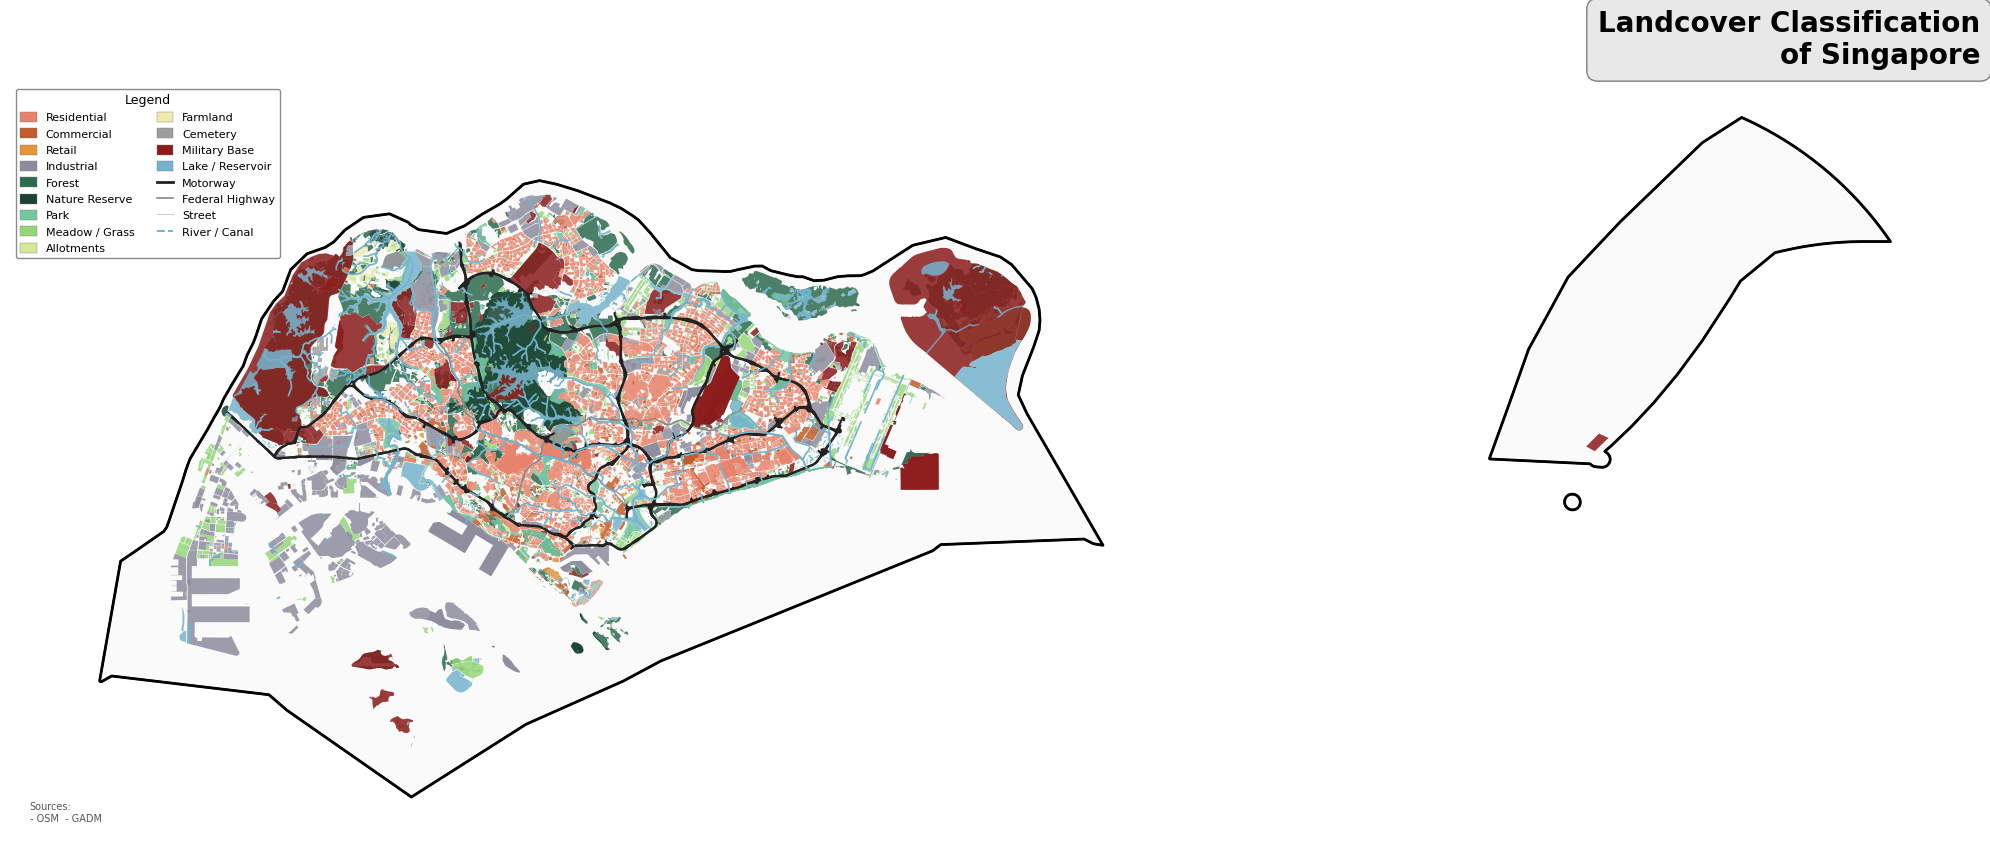

Map saved as singapore_landcover_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# Landcover Classification Map of Singapore
# Run in Google Colab
# ============================================================

# ── 1. Install ───────────────────────────────────────────────
!pip install osmnx geopandas matplotlib shapely -q

# ── 2. Imports ───────────────────────────────────────────────
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

# ── 3. Configuration ─────────────────────────────────────────
PLACE_NAME = 'Singapore'

LAYER_STYLES = {
    'Residential':       {'color': '#E8826A', 'zorder': 2},
    'Commercial':        {'color': '#C45B2A', 'zorder': 3},
    'Retail':            {'color': '#E8943A', 'zorder': 3},
    'Industrial':        {'color': '#8C8C9E', 'zorder': 3},
    'Forest':            {'color': '#2D6A4F', 'zorder': 2},
    'Nature Reserve':    {'color': '#1B4332', 'zorder': 2},
    'Park':              {'color': '#74C69D', 'zorder': 2},
    'Meadow / Grass':    {'color': '#95D67A', 'zorder': 2},
    'Allotments':        {'color': '#D4E89A', 'zorder': 2},
    'Farmland':          {'color': '#F0EAB0', 'zorder': 1},
    'Cemetery':          {'color': '#9E9E9E', 'zorder': 2},
    'Military Base':     {'color': '#8B1A1A', 'zorder': 3},
    'Lake / Reservoir':  {'color': '#74B3CE', 'zorder': 4},
    'Vineyard':          {'color': '#D8A0D8', 'zorder': 2},
}

LAYER_QUERIES = [
    ('Farmland',       {'landuse': ['farmland', 'farm', 'agriculture']}),
    ('Forest',         {'landuse': ['forest'], 'natural': ['wood']}),
    ('Nature Reserve', {'leisure': ['nature_reserve'], 'boundary': ['protected_area']}),
    ('Meadow / Grass', {'landuse': ['meadow', 'grass'], 'natural': ['grassland', 'scrub']}),
    ('Allotments',     {'landuse': ['allotments', 'orchard', 'plant_nursery']}),
    ('Cemetery',       {'landuse': ['cemetery'], 'amenity': ['grave_yard']}),
    ('Military Base',  {'landuse': ['military'], 'military': ['barracks', 'base', 'danger_area']}),
    ('Park',           {'leisure': ['park', 'garden', 'recreation_ground', 'playground']}),
    ('Residential',    {'landuse': ['residential']}),
    ('Commercial',     {'landuse': ['commercial', 'office']}),
    ('Retail',         {'landuse': ['retail', 'shops']}),
    ('Industrial',     {'landuse': ['industrial', 'port', 'logistics']}),
    ('Lake / Reservoir', {'natural': ['water'], 'landuse': ['reservoir', 'basin']}),
    ('Vineyard',       {'landuse': ['vineyard']}),
]

# ── 4. Download Boundary ──────────────────────────────────────
print(f'Downloading boundary of {PLACE_NAME}...')
boundary_gdf  = ox.geocode_to_gdf(PLACE_NAME)
boundary_proj = boundary_gdf.to_crs('EPSG:3414')  # SVY21 — Singapore CRS
print('Boundary downloaded.')

# ── 5. Download Land-Cover Layers ─────────────────────────────
layers = {}

for layer_name, tags in LAYER_QUERIES:
    collected = []
    for tag_key, tag_values in tags.items():
        try:
            gdf = ox.features_from_place(PLACE_NAME, tags={tag_key: tag_values})
            polygons = gdf[gdf.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
            if not polygons.empty:
                collected.append(polygons[['geometry']].copy())
        except Exception:
            pass  # Tag not present — skip silently

    if collected:
        merged = gpd.GeoDataFrame(
            gpd.pd.concat(collected, ignore_index=True),
            crs='EPSG:4326'
        ).to_crs('EPSG:3414')
        layers[layer_name] = merged
        print(f'  ✓ {layer_name}: {len(merged)} features')
    else:
        print(f'  – {layer_name}: no features found')

print('\nAll land-cover layers downloaded!')

# ── 6. Download Roads ─────────────────────────────────────────
print('Downloading road network...')

ROAD_QUERIES = {
    'Motorway':        ['motorway', 'motorway_link'],
    'Federal Highway': ['trunk', 'trunk_link', 'primary', 'primary_link'],
    'Street':          ['secondary', 'tertiary', 'residential', 'unclassified'],
}

roads = {}
for road_type, hw_values in ROAD_QUERIES.items():
    try:
        G = ox.graph_from_place(
            PLACE_NAME,
            custom_filter=f'["highway"~"{"|}".join(hw_values)}"]'
        )
        edges = ox.graph_to_gdfs(G, nodes=False)
        roads[road_type] = edges.to_crs('EPSG:3414')
        print(f'  ✓ {road_type}: {len(edges)} segments')
    except Exception as e:
        print(f'  – {road_type}: {e}')

# ── 7. Download Waterways ─────────────────────────────────────
print('Downloading waterways...')
try:
    rivers_gdf   = ox.features_from_place(PLACE_NAME, tags={'waterway': ['river', 'stream', 'canal']})
    rivers_lines = rivers_gdf[rivers_gdf.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
    rivers_proj  = rivers_lines[['geometry']].to_crs('EPSG:3414')
    print(f'  ✓ Rivers/waterways: {len(rivers_proj)} features')
except Exception as e:
    rivers_proj = None
    print(f'  – Waterways: {e}')

print('\nRoads and waterways downloaded!')

# ── 8. Render the Map ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(20, 16))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F5F5F0')

# Boundary fill
boundary_proj.plot(ax=ax, color='#FAFAFA', edgecolor='black', linewidth=1.5, zorder=0)

# Land-cover layers — draw bottom to top
DRAW_ORDER = [
    'Farmland', 'Forest', 'Nature Reserve', 'Meadow / Grass', 'Allotments',
    'Cemetery', 'Military Base', 'Park', 'Vineyard',
    'Residential', 'Commercial', 'Retail', 'Industrial',
    'Lake / Reservoir',
]

for layer_name in DRAW_ORDER:
    if layer_name in layers and not layers[layer_name].empty:
        style = LAYER_STYLES[layer_name]
        layers[layer_name].plot(
            ax=ax,
            color=style['color'],
            edgecolor='none',
            alpha=0.85,
            zorder=style['zorder']
        )

# Roads
ROAD_STYLES = {
    'Street':          {'color': '#CCCCCC', 'lw': 0.3, 'zorder': 5},
    'Federal Highway': {'color': '#888888', 'lw': 0.8, 'zorder': 6},
    'Motorway':        {'color': '#222222', 'lw': 1.5, 'zorder': 7},
}
for road_name, style in ROAD_STYLES.items():
    if road_name in roads:
        roads[road_name].plot(
            ax=ax,
            color=style['color'],
            linewidth=style['lw'],
            zorder=style['zorder']
        )

# Waterways
if rivers_proj is not None and not rivers_proj.empty:
    rivers_proj.plot(ax=ax, color='#74B3CE', linewidth=1.2, zorder=8)

# Boundary outline on top
boundary_proj.boundary.plot(ax=ax, color='black', linewidth=2.0, zorder=10)

# ── 9. Legend ─────────────────────────────────────────────────
legend_entries = []

for name, style in LAYER_STYLES.items():
    if name in layers:
        legend_entries.append(
            mpatches.Patch(
                facecolor=style['color'],
                edgecolor='grey', linewidth=0.3,
                label=name
            )
        )

legend_entries += [
    Line2D([0], [0], color='#222222', linewidth=2,   label='Motorway'),
    Line2D([0], [0], color='#888888', linewidth=1.2, label='Federal Highway'),
    Line2D([0], [0], color='#CCCCCC', linewidth=0.8, label='Street'),
    Line2D([0], [0], color='#74B3CE', linewidth=1.5,
           linestyle='--', label='River / Canal'),
]

ax.legend(
    handles=legend_entries,
    loc='upper left',
    ncol=2,
    fontsize=8,
    framealpha=0.9,
    edgecolor='grey',
    title='Legend',
    title_fontsize=9,
    handlelength=1.5,
    handleheight=1.0,
)

# ── 10. Title, credits, formatting ────────────────────────────
ax.set_title(
    'Landcover Classification\nof Singapore',
    fontsize=20, fontweight='bold',
    loc='right', pad=14,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8E8E8',
              edgecolor='grey', linewidth=1)
)

ax.text(
    0.01, 0.01,
    'Sources:\n- OSM  - GADM',
    transform=ax.transAxes,
    fontsize=7, color='#555555', va='bottom'
)

ax.axis('off')
plt.tight_layout()
plt.savefig('singapore_landcover_map.png', dpi=200,
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print('Map saved as singapore_landcover_map.png')

# ── 11. Download (Colab only) ──────────────────────────────────
try:
    from google.colab import files
    files.download('singapore_landcover_map.png')
except ImportError:
    print('Not in Colab — find singapore_landcover_map.png in your working directory.')